# ML for classification
## Churn project


##### Empresa telefonica A con clientes/consumidores que consumen los servicios de la empresa (TV, internet, telefono, etc). Algunos pueden no estar felices con los servicios, por lo que querrán irse a otra empres telefonica B. 

##### Hay que identificar que clientes se van a ir de la empresa A a la empresa B, y todo esto a partir de probabilidades (probabilidad de _churn_)

##### Para analizar esto, se necesita una **clasificación binaria**, que es un método de aprendizaje supervisado. 

$$ g(x_{i}) \approx y_{i} $$

##### Donde $y_{i} \in {0,1} $, siendo $1$ un ejemplo  (ya sea _churn_ o _spam_, etc) y $0$ un ejemplo negativo (es decir, _no-churn_, _no-spam_, etc). Por otro lado, $g_{i}$ tal que $g_{i} \in (0,1)$ representa de que el cliente $i-th$ _churnee_

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Validación de los datos

In [38]:
df=pd.read_csv("data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head().T

,0,1,2,3,4
customerID,7590-VHVEG,5575-GNVDE,3668-QPYBK,7795-CFOCW,9237-HQITU
gender,Female,Male,Male,Male,Female
SeniorCitizen,0,0,0,0,0
Partner,Yes,No,No,No,No
Dependents,No,No,No,No,No
tenure,1,34,2,45,2
PhoneService,No,Yes,Yes,No,Yes
MultipleLines,No phone service,No,No,No phone service,No
InternetService,DSL,DSL,DSL,DSL,Fiber optic
OnlineSecurity,No,Yes,Yes,Yes,No


In [39]:
df.columns=df.columns.str.lower().str.replace(" ","_")
categorical_columns=list(df.dtypes[df.dtypes=="object"].index)
for c in categorical_columns:
    df[c]=df[c].str.lower().str.replace(" ","_")
df.head().T

,0,1,2,3,4
customerid,7590-vhveg,5575-gnvde,3668-qpybk,7795-cfocw,9237-hqitu
gender,female,male,male,male,female
seniorcitizen,0,0,0,0,0
partner,yes,no,no,no,no
dependents,no,no,no,no,no
tenure,1,34,2,45,2
phoneservice,no,yes,yes,no,yes
multiplelines,no_phone_service,no,no,no_phone_service,no
internetservice,dsl,dsl,dsl,dsl,fiber_optic
onlinesecurity,no,yes,yes,yes,no


In [40]:
df.dtypes #totalcharges debería ser un número y seniorcitizen un objeto

customerid           object
gender               object
seniorcitizen         int64
partner              object
dependents           object
tenure                int64
phoneservice         object
multiplelines        object
internetservice      object
onlinesecurity       object
onlinebackup         object
deviceprotection     object
techsupport          object
streamingtv          object
streamingmovies      object
contract             object
paperlessbilling     object
paymentmethod        object
monthlycharges      float64
totalcharges         object
churn                object
dtype: object

In [41]:
df.totalcharges=pd.to_numeric(df.totalcharges,errors='coerce')

In [42]:
df.totalcharges=df.totalcharges.fillna(0)

In [43]:
df.totalcharges.isnull().sum()

np.int64(0)

In [44]:
#en cuanto a la variable "churn", estamos intresados no en "yes" or "no" si no más bien en unos (1) y ceros (0)
df.churn=(df.churn=="yes").astype(int)
df.churn.head()

0    0
1    0
2    1
3    0
4    1
Name: churn, dtype: int64

## Configurando el entorno de validación

Se hará lo mismo que se hizo en la sección anterior (la de regresión), pero ahora, en vez de hacerlo de forma manual, se va a hacer a través de _sickit-learn_ (los indices ya van a venir aleatorios)

In [45]:
from sklearn.model_selection import train_test_split

In [46]:
df_full_train,df_test=train_test_split(df,test_size=0.2,random_state=1)
len(df_full_train),len(df_test)

(5634, 1409)

In [47]:
df_train,df_val=train_test_split(df_full_train,test_size=0.25,random_state=1)
len(df_train),len(df_val),len(df_test)

(4225, 1409, 1409)

In [48]:
df_train=df_train.reset_index(drop=True)
df_val=df_val.reset_index(drop=True)
df_test=df_test.reset_index(drop=True)

In [49]:
y_train=df_train.churn.values
y_val=df_val.churn.values
y_test=df_test.churn.values

In [50]:
del df_train['churn']
del df_val['churn']
del df_test['churn']

## Análisis exploratorio de datos

Comprobar valores faltantes
Observar la variable objetivo
Observar variables numericas y categoricas

In [51]:
df_full_train.isnull().sum() #no hay valores faltantes

customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
churn               0
dtype: int64

In [52]:
df_full_train.churn.value_counts()

churn
0    4113
1    1521
Name: count, dtype: int64

In [53]:
df_full_train.churn.value_counts(normalize=True) #la proporción de unos (1) es la churn rate (tasa de abandono)

churn
0    0.730032
1    0.269968
Name: proportion, dtype: float64

In [54]:
global_churn_rate=df_full_train.churn.mean() #da lo mismo que el churn rate anterior
round(global_churn_rate,2)

np.float64(0.27)

In [55]:
df_full_train.dtypes

customerid           object
gender               object
seniorcitizen         int64
partner              object
dependents           object
tenure                int64
phoneservice         object
multiplelines        object
internetservice      object
onlinesecurity       object
onlinebackup         object
deviceprotection     object
techsupport          object
streamingtv          object
streamingmovies      object
contract             object
paperlessbilling     object
paymentmethod        object
monthlycharges      float64
totalcharges        float64
churn                 int64
dtype: object

In [56]:
#estamos interesados en 'tenure', 'monthlycharges' y 'totalcharges'
numeric=['tenure','monthlycharges','totalcharges']

In [57]:
df_full_train.columns

Index(['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents',
       'tenure', 'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod', 'monthlycharges', 'totalcharges', 'churn'],
      dtype='object')

In [58]:
categorical=['gender', 'seniorcitizen', 'partner', 'dependents', 'phoneservice', 'multiplelines',
       'internetservice', 'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv',
       'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod', 'churn']

In [59]:
df_full_train[categorical].nunique()

gender              2
seniorcitizen       2
partner             2
dependents          2
phoneservice        2
multiplelines       3
internetservice     3
onlinesecurity      3
onlinebackup        3
deviceprotection    3
techsupport         3
streamingtv         3
streamingmovies     3
contract            3
paperlessbilling    2
paymentmethod       4
churn               2
dtype: int64

## Importancia de las características: tasa de abandono y ratio de riesgo

¿Cuáles atributos afectan a nuestra variable objetivo?

### Churn rate

In [60]:
#churn rate en diferentes grupos
churn_female=df_full_train[df_full_train.gender=='female'].churn.mean()
churn_male=df_full_train[df_full_train.gender=='male'].churn.mean()
print(churn_female)
print(churn_male)
print(global_churn_rate)

0.27682403433476394
0.2632135306553911
0.26996805111821087


In [61]:
with_partner=df_full_train[df_full_train.partner=='yes'].churn.mean()
without_partner=df_full_train[df_full_train.partner=="no"].churn.mean()
print(with_partner)
print(without_partner)

0.20503330866025166
0.3298090040927694


La **diferencia** entre ambas tasas de abandono considerando la variable 'partner' es significativa. Si la tasa global es mayor que la particular, hay menos probabilidades de abandono. Lo contrario sucede cuando la tasa global es menor a la particular.

Por otro lado, el cociente entre ambas (la particular / la global), es una **tasa de riesgo**. Si el ratio es mayor a 1, hay mas chances de churnear, y si es menor a 1, se da el caso contrario.

La **diferencia** y el **riesgo** son muy similares, es decir, nos dan la misma información, pero de formas distintas. Con la diferencia no vemos que tan grande es una tasa de churn respecto de la otra, en cambio con el riesgo si, es decir, lo expresamos en términos relativos

In [62]:
with_partner/global_churn_rate #la tasa es 25% mas chica que la global

np.float64(0.7594724924338315)

In [63]:
without_partner/global_churn_rate #la tasa es 22% mas grande que la global

np.float64(1.2216593879412643)

In [64]:
df_group=df_full_train.groupby('gender').churn.agg(['mean','count'])
df_group['diff']=df_group['mean']-global_churn_rate
df_group['risk']=df_group['mean']/global_churn_rate
df_group

,mean,count,diff,risk
gender,,,,
female,0.276824,2796,0.006856,1.025396
male,0.263214,2838,-0.006755,0.974980


In [65]:
from IPython.display import display

In [66]:
#queremos hacer lo anterior para todas las variables categoricas
for c in categorical:
    print(c)
    df_group=df_full_train.groupby(c).churn.agg(['mean','count'])
    df_group['diff']=df_group['mean']-global_churn_rate
    df_group['risk']=df_group['mean']/global_churn_rate
    display(df_group)

gender


,mean,count,diff,risk
gender,,,,
female,0.276824,2796,0.006856,1.025396
male,0.263214,2838,-0.006755,0.974980


seniorcitizen


,mean,count,diff,risk
seniorcitizen,,,,
0,0.242270,4722,-0.027698,0.897403
1,0.413377,912,0.143409,1.531208


partner


,mean,count,diff,risk
partner,,,,
no,0.329809,2932,0.059841,1.221659
yes,0.205033,2702,-0.064935,0.759472


dependents


,mean,count,diff,risk
dependents,,,,
no,0.313760,3968,0.043792,1.162212
yes,0.165666,1666,-0.104302,0.613651


phoneservice


,mean,count,diff,risk
phoneservice,,,,
no,0.241316,547,-0.028652,0.893870
yes,0.273049,5087,0.003081,1.011412


multiplelines


,mean,count,diff,risk
multiplelines,,,,
no,0.257407,2700,-0.012561,0.953474
no_phone_service,0.241316,547,-0.028652,0.893870
yes,0.290742,2387,0.020773,1.076948


internetservice


,mean,count,diff,risk
internetservice,,,,
dsl,0.192347,1934,-0.077621,0.712482
fiber_optic,0.425171,2479,0.155203,1.574895
no,0.077805,1221,-0.192163,0.288201


onlinesecurity


,mean,count,diff,risk
onlinesecurity,,,,
no,0.420921,2801,0.150953,1.559152
no_internet_service,0.077805,1221,-0.192163,0.288201
yes,0.153226,1612,-0.116742,0.567570


onlinebackup


,mean,count,diff,risk
onlinebackup,,,,
no,0.404323,2498,0.134355,1.497672
no_internet_service,0.077805,1221,-0.192163,0.288201
yes,0.217232,1915,-0.052736,0.804660


deviceprotection


,mean,count,diff,risk
deviceprotection,,,,
no,0.395875,2473,0.125907,1.466379
no_internet_service,0.077805,1221,-0.192163,0.288201
yes,0.230412,1940,-0.039556,0.853480


techsupport


,mean,count,diff,risk
techsupport,,,,
no,0.418914,2781,0.148946,1.551717
no_internet_service,0.077805,1221,-0.192163,0.288201
yes,0.159926,1632,-0.110042,0.592390


streamingtv


,mean,count,diff,risk
streamingtv,,,,
no,0.342832,2246,0.072864,1.269897
no_internet_service,0.077805,1221,-0.192163,0.288201
yes,0.302723,2167,0.032755,1.121328


streamingmovies


,mean,count,diff,risk
streamingmovies,,,,
no,0.338906,2213,0.068938,1.255358
no_internet_service,0.077805,1221,-0.192163,0.288201
yes,0.307273,2200,0.037305,1.138182


contract


,mean,count,diff,risk
contract,,,,
month-to-month,0.431701,3104,0.161733,1.599082
one_year,0.120573,1186,-0.149395,0.446621
two_year,0.028274,1344,-0.241694,0.104730


paperlessbilling


,mean,count,diff,risk
paperlessbilling,,,,
no,0.172071,2313,-0.097897,0.637375
yes,0.338151,3321,0.068183,1.252560


paymentmethod


,mean,count,diff,risk
paymentmethod,,,,
bank_transfer_(automatic),0.168171,1219,-0.101797,0.622928
credit_card_(automatic),0.164339,1217,-0.105630,0.608733
electronic_check,0.455890,1893,0.185922,1.688682
mailed_check,0.193870,1305,-0.076098,0.718121


churn


,mean,count,diff,risk
churn,,,,
0,0.0,4113,-0.269968,0.000000
1,1.0,1521,0.730032,3.704142


## Importancia de las características: información mutua

Sirve para variables **categóricas**

La **información mutua** o **transinformación** o **ganancia de información** de dos variables aleatorias es una cantidad que mide la dependencia estadística entre ambas variables. Más precisamente, mide la información o reducción de la incertidumbre (entropía) de una variable aleatoria, $X$, debido al conocimiento del valor de otra variable aleatoria $Y$.

In [67]:
from sklearn.metrics import mutual_info_score

In [68]:
mutual_info_score(df_full_train.churn,df_full_train.contract)

0.0983203874041556

In [69]:
# se lo aplicamos atodas las variables
def mutual_information_churn_score(series):
    return mutual_info_score(series,df_full_train.churn)

In [70]:
df_full_train[categorical].apply(mutual_information_churn_score)

gender              0.000117
seniorcitizen       0.009410
partner             0.009968
dependents          0.012346
phoneservice        0.000229
multiplelines       0.000857
internetservice     0.055868
onlinesecurity      0.063085
onlinebackup        0.046923
deviceprotection    0.043453
techsupport         0.061032
streamingtv         0.031853
streamingmovies     0.031581
contract            0.098320
paperlessbilling    0.017589
paymentmethod       0.043210
churn               0.583227
dtype: float64

## Importancia de las características: coeficiente de correlación

Sirve para variables **numéricas**

Sirve para medir dependencia entre dos variables $X,Y$. En este caso, $Y \in \{0,1\}$ y $X \in \real$

In [71]:
df_full_train[numeric].corrwith(df_full_train.churn)

tenure           -0.351885
monthlycharges    0.196805
totalcharges     -0.196353
dtype: float64

In [72]:
df_full_train[df_full_train.tenure<=2].churn.mean()

np.float64(0.5953420669577875)

In [73]:
df_full_train[(df_full_train.tenure>2)&(df_full_train.tenure<=12)].churn.mean()

np.float64(0.3994413407821229)

In [74]:
df_full_train[df_full_train.tenure>12].churn.mean()

np.float64(0.17634908339788277)

In [75]:
df_full_train[df_full_train.tenure<=2].churn.mean()

np.float64(0.5953420669577875)

## Codificación de variable activa (*one-hot encoding*)

Ahora se hará con **scikit-learn**

Básicamente consiste en hacer una columna por cada categoría que se tenga, donde cada celda va a poder tomer los valores $0$ o $1$ según se de o no esa categoría para una fila particular

In [76]:
from sklearn.feature_extraction import DictVectorizer

In [77]:
dicts=df_train[['gender','contract','tenure']].iloc[:100].to_dict(orient='records')

In [78]:
dv=DictVectorizer(sparse=False)

In [79]:
dv.fit(dicts)

DictVectorizer(sparse=False)

In [80]:
dv.transform(dicts)

array([[ 0.,  0.,  1.,  1.,  0., 72.],
       [ 1.,  0.,  0.,  0.,  1., 10.],
       [ 1.,  0.,  0.,  1.,  0.,  5.],
       [ 1.,  0.,  0.,  1.,  0.,  5.],
       [ 0.,  0.,  1.,  1.,  0., 18.],
       [ 1.,  0.,  0.,  0.,  1.,  4.],
       [ 1.,  0.,  0.,  0.,  1.,  1.],
       [ 1.,  0.,  0.,  1.,  0.,  1.],
       [ 0.,  0.,  1.,  1.,  0., 72.],
       [ 1.,  0.,  0.,  1.,  0.,  6.],
       [ 0.,  0.,  1.,  1.,  0., 72.],
       [ 1.,  0.,  0.,  0.,  1., 17.],
       [ 0.,  0.,  1.,  1.,  0., 66.],
       [ 1.,  0.,  0.,  1.,  0.,  2.],
       [ 1.,  0.,  0.,  1.,  0.,  4.],
       [ 1.,  0.,  0.,  0.,  1.,  3.],
       [ 0.,  0.,  1.,  1.,  0., 71.],
       [ 1.,  0.,  0.,  1.,  0., 32.],
       [ 0.,  1.,  0.,  0.,  1., 53.],
       [ 0.,  0.,  1.,  0.,  1., 56.],
       [ 1.,  0.,  0.,  0.,  1., 61.],
       [ 0.,  1.,  0.,  1.,  0., 41.],
       [ 1.,  0.,  0.,  1.,  0.,  1.],
       [ 0.,  0.,  1.,  1.,  0.,  3.],
       [ 1.,  0.,  0.,  0.,  1.,  3.],
       [ 0.,  0.,  1.,  0

In [81]:
# si queremos tomar todas las variables
categorical=['gender', 'seniorcitizen', 'partner', 'dependents', 'phoneservice', 'multiplelines',
       'internetservice', 'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv',
       'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod']
train_dicts=df_train[categorical+numeric].to_dict(orient='records')
val_dicts=df_val[categorical+numeric].to_dict(orient='records')


In [82]:
train_dicts[0]

{'gender': 'female',
 'seniorcitizen': 0,
 'partner': 'yes',
 'dependents': 'yes',
 'phoneservice': 'yes',
 'multiplelines': 'yes',
 'internetservice': 'fiber_optic',
 'onlinesecurity': 'yes',
 'onlinebackup': 'yes',
 'deviceprotection': 'yes',
 'techsupport': 'yes',
 'streamingtv': 'yes',
 'streamingmovies': 'yes',
 'contract': 'two_year',
 'paperlessbilling': 'yes',
 'paymentmethod': 'electronic_check',
 'tenure': 72,
 'monthlycharges': 115.5,
 'totalcharges': 8425.15}

In [83]:
dv=DictVectorizer(sparse=False)

In [84]:
X_train=dv.fit_transform(train_dicts)
X_val=dv.transform(val_dicts)

In [85]:
dv=DictVectorizer(sparse=False)

train_dicts=df_train[categorical+numeric].to_dict(orient='records')
X_train=dv.fit_transform(train_dicts)

val_dicts=df_val[categorical+numeric].to_dict(orient='records')
X_val=dv.transform(val_dicts)

## Regresión logística

Recordando nuestro modelo, $g(x_{i})=y_{i}$, $y_{i}$ es nuestro target, y puede obtenerse a partir de un problema de regresión o clasificación. Estos últimos pueden dar resultados binarios o multiclase. En este caso, nos enfocamos en la clasificación **binaria**, es decir, la que puede dar $0$ o $1$ (ej: spam, churn, impago, etc). $g(x_{i})$ es una probabilidad y su forma funcional es un sigmoide que puede tomar como valor máximo a uno.

La forma funcional de un sigmoide es 

$$\frac{1}{1+\exp(-z)}$$

In [86]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

In [87]:
z=np.linspace(-10,10,51)
z

array([-10. ,  -9.6,  -9.2,  -8.8,  -8.4,  -8. ,  -7.6,  -7.2,  -6.8,
        -6.4,  -6. ,  -5.6,  -5.2,  -4.8,  -4.4,  -4. ,  -3.6,  -3.2,
        -2.8,  -2.4,  -2. ,  -1.6,  -1.2,  -0.8,  -0.4,   0. ,   0.4,
         0.8,   1.2,   1.6,   2. ,   2.4,   2.8,   3.2,   3.6,   4. ,
         4.4,   4.8,   5.2,   5.6,   6. ,   6.4,   6.8,   7.2,   7.6,
         8. ,   8.4,   8.8,   9.2,   9.6,  10. ])

In [88]:
sigmoid(z)

array([4.53978687e-05, 6.77241496e-05, 1.01029194e-04, 1.50710358e-04,
       2.24816770e-04, 3.35350130e-04, 5.00201107e-04, 7.46028834e-04,
       1.11253603e-03, 1.65880108e-03, 2.47262316e-03, 3.68423990e-03,
       5.48629890e-03, 8.16257115e-03, 1.21284350e-02, 1.79862100e-02,
       2.65969936e-02, 3.91657228e-02, 5.73241759e-02, 8.31726965e-02,
       1.19202922e-01, 1.67981615e-01, 2.31475217e-01, 3.10025519e-01,
       4.01312340e-01, 5.00000000e-01, 5.98687660e-01, 6.89974481e-01,
       7.68524783e-01, 8.32018385e-01, 8.80797078e-01, 9.16827304e-01,
       9.42675824e-01, 9.60834277e-01, 9.73403006e-01, 9.82013790e-01,
       9.87871565e-01, 9.91837429e-01, 9.94513701e-01, 9.96315760e-01,
       9.97527377e-01, 9.98341199e-01, 9.98887464e-01, 9.99253971e-01,
       9.99499799e-01, 9.99664650e-01, 9.99775183e-01, 9.99849290e-01,
       9.99898971e-01, 9.99932276e-01, 9.99954602e-01])

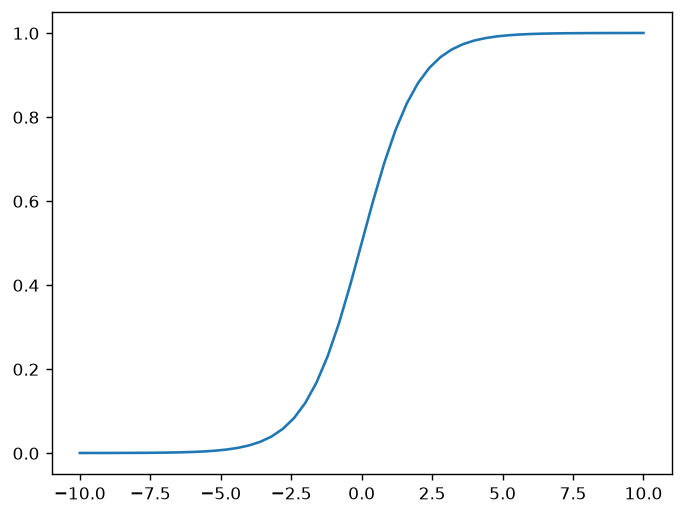

In [89]:
plt.plot(z,sigmoid(z))

In [90]:
def logistic_regression(xi):
    score=w0

    for j in range(len(w)):
        score=score+xi[j]*w[j]

    result=sigmoid(score)
    return result

## Entrenando un modelo de regresión logistica con *scikit-learn*

In [91]:
from sklearn.linear_model import LogisticRegression

In [92]:
model=LogisticRegression()
model.fit(X_train,y_train)

C:\Users\SYC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [93]:
model.coef_[0].round(3) # estos son los w

array([ 0.476, -0.175, -0.408, -0.03 , -0.078,  0.063, -0.089, -0.081,
       -0.034, -0.073, -0.336,  0.317, -0.089,  0.004, -0.258,  0.142,
        0.009,  0.063, -0.089, -0.081,  0.266, -0.089, -0.284, -0.231,
        0.123, -0.166,  0.059, -0.087, -0.032,  0.07 , -0.059,  0.142,
       -0.25 ,  0.216, -0.121, -0.089,  0.102, -0.071, -0.089,  0.052,
        0.213, -0.089, -0.232, -0.07 ,  0.   ])

In [94]:
model.intercept_[0].round(3)

np.float64(-0.109)

In [95]:
model.predict(X_train) #hard predictions

array([0, 1, 1, ..., 1, 0, 1], shape=(4225,))

In [96]:
model.predict_proba(X_train) #soft predictions. son dos columnas. a la izquierda, la probabilidad de que sea 0 y a la derecha la probabilidad de que sea 1 (churning)

array([[0.90452492, 0.09547508],
       [0.32058285, 0.67941715],
       [0.36630247, 0.63369753],
       ...,
       [0.46766799, 0.53233201],
       [0.95761329, 0.04238671],
       [0.3012034 , 0.6987966 ]], shape=(4225, 2))

In [97]:
y_pred=model.predict_proba(X_val)[:,1]
y_pred

array([0.00896799, 0.20454216, 0.21215178, ..., 0.1363222 , 0.79995367,
       0.83758207], shape=(1409,))

In [98]:
churn_decision=y_pred>=0.5
churn_decision

array([False, False, False, ..., False,  True,  True], shape=(1409,))

In [99]:
df_val[churn_decision].customerid #aca tengo solo los id que van a churnear para mandarle un mail con descuento

3       8433-wxgna
8       3440-jpscl
11      2637-fkfsy
12      7228-omtpn
19      6711-fldfb
           ...    
1397    5976-jcjrh
1398    2034-cgrhz
1399    5276-kqwhg
1407    6521-yytyi
1408    3049-solay
Name: customerid, Length: 312, dtype: object

In [100]:
# que tan preciso es nuestro modelo?
churn_decision.astype(int)

array([0, 0, 0, ..., 0, 1, 1], shape=(1409,))

In [101]:
(y_val==churn_decision).mean()

np.float64(0.8026969481902059)

In [102]:
df_pred=pd.DataFrame()
df_pred['probability']=y_pred
df_pred['prediction']=churn_decision.astype(int)
df_pred['actual']=y_val
df_pred['correct']=df_pred.prediction==df_pred.actual
df_pred

,probability,prediction,actual,correct
0,0.008968,0,0,True
1,0.204542,0,0,True
2,0.212152,0,0,True
3,0.543024,1,1,True
4,0.213658,0,0,True
...,...,...,...,...
1404,0.313711,0,0,True
1405,0.039280,0,1,False
1406,0.136322,0,0,True
1407,0.799954,1,1,True


In [103]:
 df_pred.correct.mean()

np.float64(0.8026969481902059)

## Interpretación del modelo

In [104]:
dict(zip(dv.get_feature_names_out(),model.coef_[0].round(3))) # lo que hace la función zip es linkear los valres de una lista con los valores de otra lista


{'contract=month-to-month': np.float64(0.476),
 'contract=one_year': np.float64(-0.175),
 'contract=two_year': np.float64(-0.408),
 'dependents=no': np.float64(-0.03),
 'dependents=yes': np.float64(-0.078),
 'deviceprotection=no': np.float64(0.063),
 'deviceprotection=no_internet_service': np.float64(-0.089),
 'deviceprotection=yes': np.float64(-0.081),
 'gender=female': np.float64(-0.034),
 'gender=male': np.float64(-0.073),
 'internetservice=dsl': np.float64(-0.336),
 'internetservice=fiber_optic': np.float64(0.317),
 'internetservice=no': np.float64(-0.089),
 'monthlycharges': np.float64(0.004),
 'multiplelines=no': np.float64(-0.258),
 'multiplelines=no_phone_service': np.float64(0.142),
 'multiplelines=yes': np.float64(0.009),
 'onlinebackup=no': np.float64(0.063),
 'onlinebackup=no_internet_service': np.float64(-0.089),
 'onlinebackup=yes': np.float64(-0.081),
 'onlinesecurity=no': np.float64(0.266),
 'onlinesecurity=no_internet_service': np.float64(-0.089),
 'onlinesecurity=yes'

In [105]:
#hay demasiadas features, hacemos un modelos mas pequeño
small=['contract','tenure','monthlycharges']
df_train[small].iloc[:10].to_dict(orient='records')

[{'contract': 'two_year', 'tenure': 72, 'monthlycharges': 115.5},
 {'contract': 'month-to-month', 'tenure': 10, 'monthlycharges': 95.25},
 {'contract': 'month-to-month', 'tenure': 5, 'monthlycharges': 75.55},
 {'contract': 'month-to-month', 'tenure': 5, 'monthlycharges': 80.85},
 {'contract': 'two_year', 'tenure': 18, 'monthlycharges': 20.1},
 {'contract': 'month-to-month', 'tenure': 4, 'monthlycharges': 30.5},
 {'contract': 'month-to-month', 'tenure': 1, 'monthlycharges': 75.1},
 {'contract': 'month-to-month', 'tenure': 1, 'monthlycharges': 70.3},
 {'contract': 'two_year', 'tenure': 72, 'monthlycharges': 19.75},
 {'contract': 'month-to-month', 'tenure': 6, 'monthlycharges': 109.9}]

In [106]:
dicts_train_small=df_train[small].to_dict(orient='records')
dicts_val_small=df_val[small].to_dict(orient='records')
dv_small=DictVectorizer(sparse=False)
dv_small.fit(dicts_train_small)
dv_small.get_feature_names_out()

array(['contract=month-to-month', 'contract=one_year',
       'contract=two_year', 'monthlycharges', 'tenure'], dtype=object)

In [107]:
X_train_small=dv_small.transform(dicts_train_small)

In [108]:
model_small=LogisticRegression()
model_small.fit(X_train_small,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [109]:
model_small.intercept_[0]

np.float64(-2.477957596026966)

In [110]:
model_small.coef_[0].round(3)

array([ 0.971, -0.024, -0.948,  0.027, -0.036])

In [111]:
dict(zip(dv_small.get_feature_names_out(),model_small.coef_[0].round(3)))

{'contract=month-to-month': np.float64(0.971),
 'contract=one_year': np.float64(-0.024),
 'contract=two_year': np.float64(-0.948),
 'monthlycharges': np.float64(0.027),
 'tenure': np.float64(-0.036)}

## Usando el modelo

In [112]:
dicts_full_train=df_full_train[categorical+numeric].to_dict(orient='records')
dicts_full_train[:3]

[{'gender': 'male',
  'seniorcitizen': 0,
  'partner': 'yes',
  'dependents': 'yes',
  'phoneservice': 'yes',
  'multiplelines': 'no',
  'internetservice': 'no',
  'onlinesecurity': 'no_internet_service',
  'onlinebackup': 'no_internet_service',
  'deviceprotection': 'no_internet_service',
  'techsupport': 'no_internet_service',
  'streamingtv': 'no_internet_service',
  'streamingmovies': 'no_internet_service',
  'contract': 'two_year',
  'paperlessbilling': 'no',
  'paymentmethod': 'mailed_check',
  'tenure': 12,
  'monthlycharges': 19.7,
  'totalcharges': 258.35},
 {'gender': 'female',
  'seniorcitizen': 0,
  'partner': 'no',
  'dependents': 'no',
  'phoneservice': 'yes',
  'multiplelines': 'no',
  'internetservice': 'dsl',
  'onlinesecurity': 'yes',
  'onlinebackup': 'yes',
  'deviceprotection': 'yes',
  'techsupport': 'yes',
  'streamingtv': 'no',
  'streamingmovies': 'yes',
  'contract': 'one_year',
  'paperlessbilling': 'no',
  'paymentmethod': 'credit_card_(automatic)',
  'tenur

In [113]:
dv=DictVectorizer(sparse=False)
X_full_train=dv.fit_transform(dicts_full_train)

In [114]:
y_full_train=df_full_train.churn.values

In [115]:
model=LogisticRegression()
model.fit(X_full_train,y_full_train)

C:\Users\SYC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [116]:
dicts_test=df_test[categorical+numeric].to_dict(orient='records')
dicts_test[:3]

[{'gender': 'female',
  'seniorcitizen': 0,
  'partner': 'no',
  'dependents': 'no',
  'phoneservice': 'yes',
  'multiplelines': 'no',
  'internetservice': 'dsl',
  'onlinesecurity': 'yes',
  'onlinebackup': 'no',
  'deviceprotection': 'yes',
  'techsupport': 'yes',
  'streamingtv': 'yes',
  'streamingmovies': 'yes',
  'contract': 'one_year',
  'paperlessbilling': 'yes',
  'paymentmethod': 'bank_transfer_(automatic)',
  'tenure': 41,
  'monthlycharges': 79.85,
  'totalcharges': 3320.75},
 {'gender': 'female',
  'seniorcitizen': 1,
  'partner': 'no',
  'dependents': 'no',
  'phoneservice': 'yes',
  'multiplelines': 'yes',
  'internetservice': 'fiber_optic',
  'onlinesecurity': 'yes',
  'onlinebackup': 'no',
  'deviceprotection': 'no',
  'techsupport': 'no',
  'streamingtv': 'yes',
  'streamingmovies': 'yes',
  'contract': 'two_year',
  'paperlessbilling': 'yes',
  'paymentmethod': 'bank_transfer_(automatic)',
  'tenure': 66,
  'monthlycharges': 102.4,
  'totalcharges': 6471.85},
 {'gend

In [117]:
X_test=dv.transform(dicts_test)

In [118]:
Y_pred=model.predict_proba(X_test)[:,1]

In [119]:
churn_decision=(Y_pred>=0.5)
churn_decision

array([False, False, False, ..., False, False,  True], shape=(1409,))

In [120]:
(churn_decision==y_test).mean()

np.float64(0.8140525195173882)

In [121]:
#ejemplo de un cliente random
customer=dicts_test[-1]
customer

{'gender': 'female',
 'seniorcitizen': 0,
 'partner': 'yes',
 'dependents': 'yes',
 'phoneservice': 'yes',
 'multiplelines': 'yes',
 'internetservice': 'fiber_optic',
 'onlinesecurity': 'yes',
 'onlinebackup': 'no',
 'deviceprotection': 'yes',
 'techsupport': 'no',
 'streamingtv': 'yes',
 'streamingmovies': 'yes',
 'contract': 'month-to-month',
 'paperlessbilling': 'yes',
 'paymentmethod': 'electronic_check',
 'tenure': 17,
 'monthlycharges': 104.2,
 'totalcharges': 1743.5}

In [122]:
X_small=dv.transform([customer])

In [123]:
model.predict_proba(X_small) #no churnearía (prob de 0.49)

array([[0.34157989, 0.65842011]])

In [124]:
#churnea?
y_test[-1]
#no churnea

np.int64(1)

## Precisión y modelo 'tonto'

La precisión se calcula como el total de sujetos bien clasificados sobre el total de sujetos. 

El threshold no necesariamente es de 0.5, si no que va a depender más bien del negocio

In [125]:
len(y_val)

1409

In [126]:
#a cada observación, le asignamos un score. si es mayor a 0,5, churnea. si es menor, lo contrario
(y_val==churn_decision).sum()

np.int64(869)

In [127]:
(y_val==churn_decision).mean()

np.float64(0.6167494677075941)

In [129]:
from sklearn.metrics import accuracy_score

#cambiamos el threshold
thresholds=np.linspace(0,1,21)
scores=[]
for t in thresholds:
    score=accuracy_score(y_val,y_pred>=t)
    print("Threshold: %.2f, Score: %.4f" % (t,score))
    scores.append(score)

Threshold: 0.00, Score: 0.2740
Threshold: 0.05, Score: 0.5103
Threshold: 0.10, Score: 0.5919
Threshold: 0.15, Score: 0.6671
Threshold: 0.20, Score: 0.7097
Threshold: 0.25, Score: 0.7388
Threshold: 0.30, Score: 0.7601
Threshold: 0.35, Score: 0.7722
Threshold: 0.40, Score: 0.7850
Threshold: 0.45, Score: 0.7942
Threshold: 0.50, Score: 0.8027
Threshold: 0.55, Score: 0.8013
Threshold: 0.60, Score: 0.7956
Threshold: 0.65, Score: 0.7864
Threshold: 0.70, Score: 0.7658
Threshold: 0.75, Score: 0.7445
Threshold: 0.80, Score: 0.7339
Threshold: 0.85, Score: 0.7260
Threshold: 0.90, Score: 0.7260
Threshold: 0.95, Score: 0.7260
Threshold: 1.00, Score: 0.7260


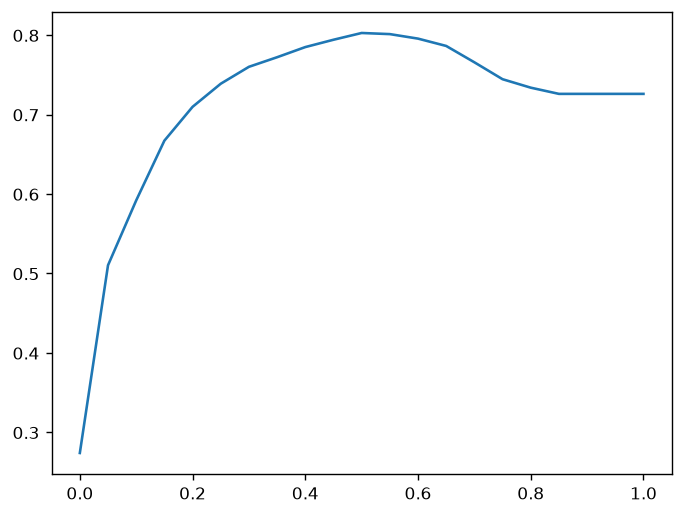

In [130]:
plt.plot(thresholds,scores)

Si se presta atención, se puede observar que el hecho de utilizar un _threshold_ de $1$, el modelo tiene una precisión unicamente 7 puntos porcentuales por debajo del score para el mejor _threshold_. Ese modelo sería el modelo 'tonto'.

Y ese es el principal problema con la "precisión", al menos en nuestro caso donde los datos estan "desbalanceados" (hay muchos que no churnean y pocos que sí)

## Matriz de confusión

Una forma de ver distintos tipos de errores: false positive, false negative, true positive y true negative.

Por un lado separamos los datos de validación con la cantidad de agentes que churnearon y a cantidad de los que no. Luego separamos los datos de la función $g(x)$ para separar también los que churnearon y los que no. Por último, se combinan ambos objetos para obtener la matriz de confusión con los que fueron correctamente predichos (que churnearon y que no churnearon) y los que fueron erroneamente predichos.


In [131]:
#gente que churnea
threshold=0.5
actual_positive=(y_val==1)
actual_negative=(y_val==0)
predict_positive=(y_pred>=threshold)
predict_negative=(y_pred<threshold)

In [132]:
tp=(predict_positive & actual_positive).sum() #true positives
tn=(predict_negative & actual_negative).sum() #true negatives
fp=(predict_positive & actual_negative).sum() #false positives
fn=(predict_negative & actual_positive).sum() #false negatives

In [133]:
confusion_matrix=np.array([
    [tn,fp],
    [fn,tp]
])
confusion_matrix

array([[921, 102],
       [176, 210]])

In [134]:
confusion_matrix/confusion_matrix.sum() 

array([[0.65365507, 0.07239177],
       [0.12491128, 0.14904187]])

## Precisión, _recall_ y _accuracy_

**Precisión**: fracción de predicciones positivas que son correctas. Es decir, nos interesamos unicamente en las predicciones positivas.

$$Precision=\frac{TP}{TP+FP}$$

**Exhaustividad o _recall_**: fracción de predicciones positivas correctamente identificadas.

$$Recall=\frac{TP}{TP+FN}$$

**Efectividad o _accuracy_**: predicciones correctas en términos de las predicciones totales.

$$Accuracy=\frac{TN+TP}{TN+TP+FP+FN}$$

No todas las metricas tienen el mismo valor de uso. Su utilidad va a depender del contexto del problema que se esté planteando. Por ejemplo, podemos tener un nivel muy alto de _accuracy_, pero ocasionado por los datos inbalanceados. De esta forma, es importante observar todas las métricas, y no solo una

In [135]:
p=tp/(tp+fp)
p 

np.float64(0.6730769230769231)

In [136]:
r=tp/(tp+fn)
r

np.float64(0.5440414507772021)

In [137]:
a=(tp+tn)/len(y_val)
a

np.float64(0.8026969481902059)

## Curvas ROC (_receiver operating characteristics_)

Se utilizan dos métricas: la **tasa de falsos positivos (FPR)* y la **tasa de verdaderos positivos (TPR)**

$$FPR=\frac{FP}{TN+FP}$$

$$TPR=\frac{TP}{TP+FN}$$

Queremos minimizar los FP y maximizar los TP

Las curvas ROC miran todos los _thresholds_ posibles

In [138]:
tpr=tp/(tp+fn) #lo mismo que el recall 
fpr=fp/(fp+tn) 

In [139]:
scores=[]
threshold=np.linspace(0,1,101)

for t in thresholds:
    actual_positive=(y_val==1)
    actual_negative=(y_val==0)
    predict_positive=(y_pred>=t)
    predict_negative=(y_pred<t)
    tp=(predict_positive & actual_positive).sum() #true positives
    tn=(predict_negative & actual_negative).sum() #true negatives
    fp=(predict_positive & actual_negative).sum() #false positives
    fn=(predict_negative & actual_positive).sum() #false negatives
    scores.append((t,tp,fp,fn,tn))

df_scores=pd.DataFrame(scores,columns=['threshold','tp','fp','fn','tn'])

In [140]:
df_scores[::1]

,threshold,tp,fp,fn,tn
0,0.00,386,1023,0,0
1,0.05,379,683,7,340
2,0.10,366,555,20,468
3,0.15,351,434,35,589
4,0.20,333,356,53,667
5,0.25,309,291,77,732
6,0.30,284,236,102,787
7,0.35,272,207,114,816
8,0.40,249,166,137,857
9,0.45,230,134,156,889


In [141]:
df_scores['tpr']=df_scores.tp/(df_scores.tp+df_scores.fn)
df_scores['fpr']=df_scores.fp/(df_scores.fp+df_scores.tn) 
df_scores

,threshold,tp,fp,fn,tn,tpr,fpr
0,0.00,386,1023,0,0,1.000000,1.000000
1,0.05,379,683,7,340,0.981865,0.667644
2,0.10,366,555,20,468,0.948187,0.542522
3,0.15,351,434,35,589,0.909326,0.424242
4,0.20,333,356,53,667,0.862694,0.347996
5,0.25,309,291,77,732,0.800518,0.284457
6,0.30,284,236,102,787,0.735751,0.230694
7,0.35,272,207,114,816,0.704663,0.202346
8,0.40,249,166,137,857,0.645078,0.162268
9,0.45,230,134,156,889,0.595855,0.130987


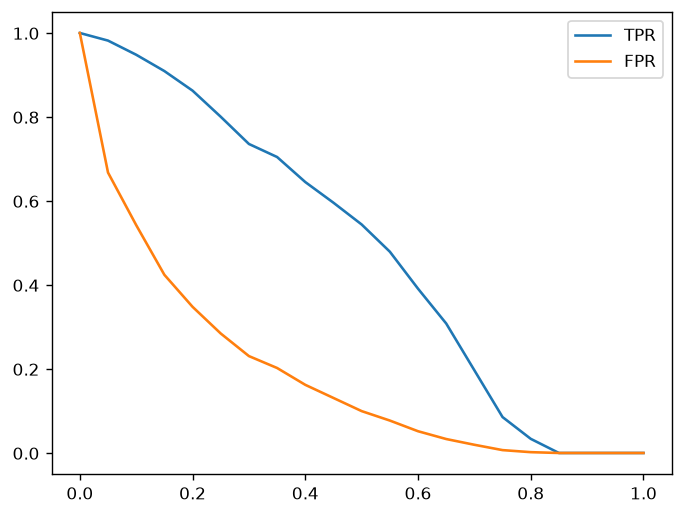

In [142]:
plt.plot(df_scores.threshold,df_scores['tpr'],label='TPR')
plt.plot(df_scores.threshold,df_scores['fpr'],label='FPR')
plt.legend()

#### Modelo aleatorio de _churn_ para comparación

La curva ROC aún no nos da _insights_ porque no tenemos con que compraralo. Aún así, nos va a servir como _baseline_

In [143]:
y_rand=np.random.uniform(0,1,size=len(y_val))

In [144]:
((y_rand>=0.5)==y_val).mean()

np.float64(0.49751596877217885)

In [145]:
def tpr_fpr_dataframe(y_val,y_pred):
    scores=[]
    threshold=np.linspace(0,1,101)

    for t in thresholds:
        actual_positive=(y_val==1)
        actual_negative=(y_val==0)
        predict_positive=(y_pred>=t)
        predict_negative=(y_pred<t)
        tp=(predict_positive & actual_positive).sum() #true positives
        tn=(predict_negative & actual_negative).sum() #true negatives
        fp=(predict_positive & actual_negative).sum() #false positives
        fn=(predict_negative & actual_positive).sum() #false negatives
        scores.append((t,tp,fp,fn,tn))

    df_scores=pd.DataFrame(scores,columns=['threshold','tp','fp','fn','tn'])
    df_scores['tpr']=df_scores.tp/(df_scores.tp+df_scores.fn)
    df_scores['fpr']=df_scores.fp/(df_scores.fp+df_scores.tn) 

    return df_scores

In [146]:
df_rand=tpr_fpr_dataframe(y_val,y_rand)

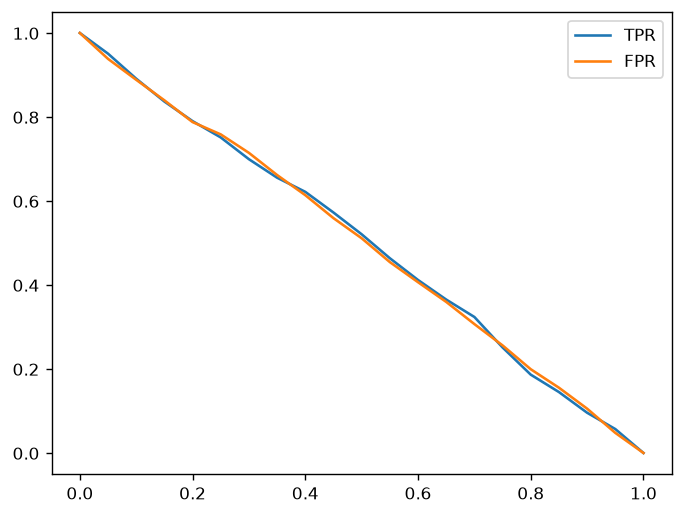

In [147]:
plt.plot(df_rand.threshold,df_rand['tpr'],label='TPR')
plt.plot(df_rand.threshold,df_rand['fpr'],label='FPR')
plt.legend()

#### Modelo ideal

Consiste en ordenar todos los individuos (en este caso) de menor a mayor probabilidad de que churnee. Esto va a mostrar que a partir de cierto _threshold_, todos los sujetos cominenzan a churnear, por lo que se elegiría esé _threshold_ que luego ocasionará un 100% de accuracy

In [148]:
num_neg=(y_val==0).sum()
num_pos=(y_val==1).sum()
num_neg,num_pos

(np.int64(1023), np.int64(386))

In [149]:
y_ideal=np.repeat([0,1],[num_neg,num_pos]) #y_ideal es como nuestro validation set, por lo que esta ordenado
y_ideal

array([0, 0, 0, ..., 1, 1, 1], shape=(1409,))

In [150]:
y_ideal_predictions=np.linspace(0,1,len(y_val))

In [151]:
((y_ideal_predictions>=0.726)==y_ideal).mean()

np.float64(1.0)

In [152]:
df_ideal=tpr_fpr_dataframe(y_ideal,y_ideal_predictions)

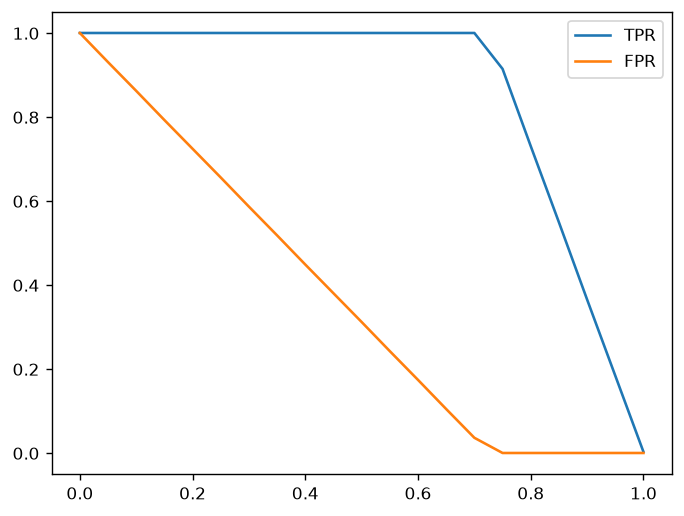

In [153]:
plt.plot(df_ideal.threshold,df_ideal['tpr'],label='TPR')
plt.plot(df_ideal.threshold,df_ideal['fpr'],label='FPR')
plt.legend()

#### Uniendo todo

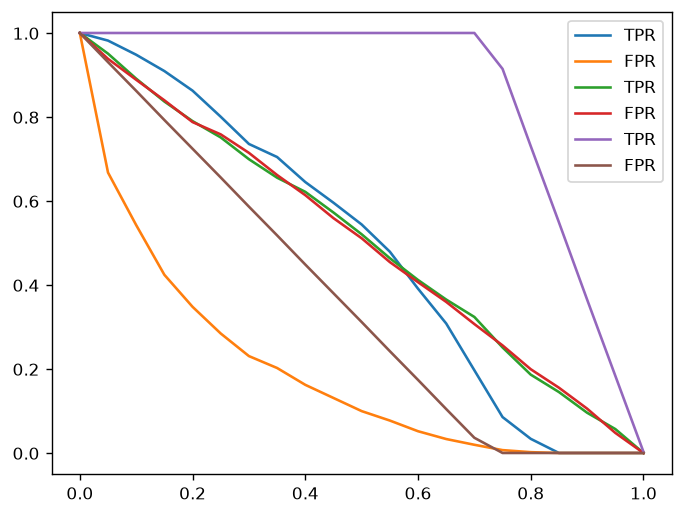

In [154]:
plt.plot(df_scores.threshold,df_scores['tpr'],label='TPR')
plt.plot(df_scores.threshold,df_scores['fpr'],label='FPR')

plt.plot(df_rand.threshold,df_rand['tpr'],label='TPR')
plt.plot(df_rand.threshold,df_rand['fpr'],label='FPR')

plt.plot(df_ideal.threshold,df_ideal['tpr'],label='TPR')
plt.plot(df_ideal.threshold,df_ideal['fpr'],label='FPR')
plt.legend()

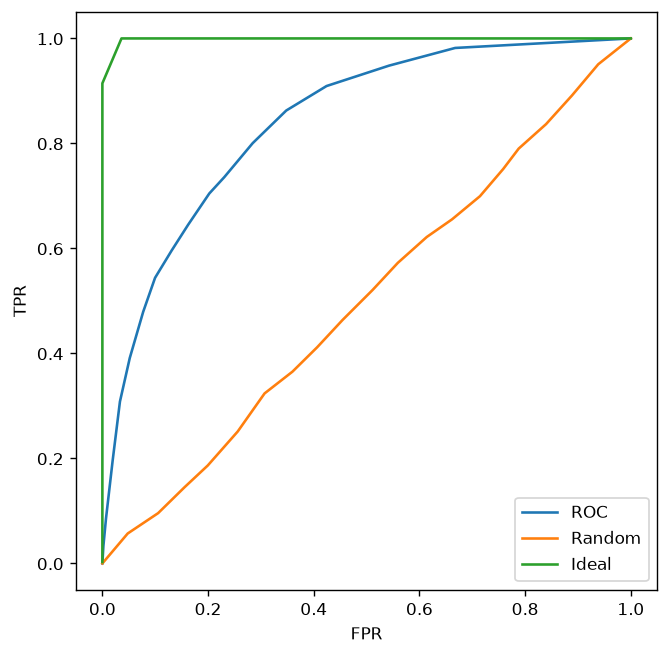

In [155]:
plt.figure(figsize=(6,6))
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.plot(df_scores.fpr,df_scores.tpr,label='ROC')
plt.plot(df_rand.fpr,df_rand.tpr,label='Random')
plt.plot(df_ideal.fpr,df_ideal.tpr,label='Ideal')
plt.legend()

Lo ideal es siempre estar lo más alejado posible de la linea "Random", que es la simulada por la distribución uniforme, es decir, como si se tratara de tirar una moneda para ver si sale cara o cruz

## ROC AUC

AUC es el área debajo de la curva ROC, y es una métrica útil que nos dice que tan cerca estamos del punto ideal en la curva ROC.

Lo ideal es que el AUC este entre 0,5 y 1, y basicamente nos dice cual es la probabilidad de que, luego de seleccionar aleatoriamente un sujeto positivo (que churneó) y un negativo (que no churneó), el primero tenga un _score_ mayor que el primero

In [156]:
from sklearn.metrics import auc
from sklearn.metrics import roc_auc_score

In [157]:
auc(df_scores.fpr,df_scores.tpr)

0.840969869174783

In [158]:
roc_auc_score(y_val,y_pred)

0.8438150517374987

In [159]:
import random

In [160]:
neg=y_pred[y_val==0]
pos=y_pred[y_val==1]

In [161]:
#siguiendo el concepto de probabilidad de la AUC
n=10000
exitos=0

for i in range(n):
    pos_ind=random.randint(0,len(pos)-1)
    neg_ind=random.randint(0,len(neg)-1)
    if pos[pos_ind]>neg[neg_ind]:
        exitos=exitos+1

exitos/n

0.8467

In [162]:
#lo anterior con numpy
n=50000
pos_ind=np.random.randint(0,len(pos),size=n)
neg_ind=np.random.randint(0,len(neg),size=n)
(pos[pos_ind]>neg[neg_ind]).mean()

np.float64(0.84384)

## _Cross-validation_

La validación cruzada implica probar el modelo, pero para muchos conjuntos de datos. En esto caso, solo separamos los datos en _train_ y _test_. Los datos de _train_ los separamos en $k$ folds, donde usaremos $k-1$ para entrenar el modelo y el restante para  validarlo.

In [163]:
def train(df,y_train,C=1.0):
    dicts=df[categorical+numeric].to_dict(orient='records') # convertir dataframe a una lista de diccionarios

    dv=DictVectorizer(sparse=False) # DictVectorizer es una clase que transforma un diccionario de datos en una matriz de características. La opción sparse=False indica que queremos una matriz densa en lugar de una matriz dispersa.
    X_train=dv.fit_transform(dicts) #fit_transform lo que hace es primero ajustar el modelo a los datos (fit) y luego transformar los datos (transform) en una matriz de características.

    model=LogisticRegression(C=C,max_iter=10000) #max_inter es el número máximo de iteraciones que se permiten para que el algoritmo converja. Si no converge, se puede aumentar este número.
    model.fit(X_train,y_train)

    return dv,model

In [ ]:
dv,model=train(df_train,y_train,C=0.001)

(DictVectorizer(sparse=False), LogisticRegression(C=0.001, max_iter=10000))

In [166]:
def predict(df,dv,model):
    dicts=df[categorical+numeric].to_dict(orient='records')
    X=dv.transform(dicts)
    y_pred=model.predict_proba(X)[:,1] #predict_proba devuelve una matriz con las probabilidades de cada clase. [:,1] selecciona la columna de probabilidades de la clase positiva.

    return y_pred

In [168]:
y_pred=predict(df_val,dv,model)
y_pred

array([0.02499804, 0.23973487, 0.24620422, ..., 0.24674241, 0.75564357,
       0.75900429], shape=(1409,))

In [169]:
from sklearn.model_selection import KFold

In [170]:
kfold=KFold(n_splits=10,shuffle=True,random_state=1) #con n_splits=10, entrenamos el 90% y validamos en el 10% restante

In [171]:
kfold.split(df_full_train) # dividir el conjunto de datos en k pliegues

<generator object _BaseKFold.split at 0x00000209C9239580>

In [175]:
train_idx,val_idx=next(kfold.split(df_full_train)) # obtener los índices de los datos para el pliegue actual. el 'next' devuelve el siguiente elemento del iterador. en este caso, devuelve los índices de los datos para el primer pliegue.

In [ ]:
from tqdm.auto import tqdm #tqdm es una librería que permite mostrar una barra de progreso en la consola. Esto es útil cuando se tienen muchos pliegues y se quiere ver el progreso del entrenamiento.

C:\Users\SYC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [177]:
n_splits=5
for C in tqdm([0.1,0.001,0.1,0.5,1,5,10]):
    kfold=KFold(n_splits=n_splits,shuffle=True,random_state=1)
    scores=[]

    for train_idx,val_idx in kfold.split(df_full_train):  # kfold.split(df_full_train) devuelve un generador que produce tuplas de índices de entrenamiento y validación para cada pliegue. En cada iteración del bucle, se obtienen los índices de entrenamiento y validación para el pliegue actual.
        df_train=df_full_train.iloc[train_idx] #seleccionamos los datos de entrenamiento para el pliegue actual usando los índices de entrenamiento obtenidos del generador kfold.split. Esto nos da un subconjunto del conjunto de datos completo que se utilizará para entrenar el modelo en este pliegue.
        df_val=df_full_train.iloc[val_idx]

        y_train=df_train.churn.values
        y_val=df_val.churn.values

        dv,model=train(df_train,y_train,C=C)
        y_pred=predict(df_val,dv,model)

        auc_score=roc_auc_score(y_val,y_pred)
        scores.append(auc_score)

    print('C=%s %.3f +- %.3f' % (C,np.mean(scores),np.std(scores)))

# lo que hace este bucle es probar diferentes valores de la hiperparámetro C y seleccionar el que da mejores resultados en términos de AUC.

 14%|█▍        | 1/7 [00:13<01:22, 13.67s/it]

C=0.1 0.842 +- 0.007


 29%|██▊       | 2/7 [00:15<00:32,  6.57s/it]

C=0.001 0.825 +- 0.009


 43%|████▎     | 3/7 [00:24<00:30,  7.56s/it]

C=0.1 0.842 +- 0.007


 57%|█████▋    | 4/7 [00:28<00:19,  6.51s/it]

C=0.5 0.842 +- 0.007


 71%|███████▏  | 5/7 [00:34<00:12,  6.05s/it]

C=1 0.842 +- 0.007


 86%|████████▌ | 6/7 [00:39<00:05,  5.88s/it]

C=5 0.842 +- 0.007


100%|██████████| 7/7 [00:45<00:00,  6.49s/it]

C=10 0.842 +- 0.007


In [178]:
dv,model=train(df_full_train,df_full_train.churn.values,C=1.0)
y_pred=predict(df_test,dv,model)
auc=roc_auc_score(y_test,y_pred)
auc

0.8584573759303195